# Modelos RL, Ridge y Lasso

In [27]:
# Librerías
import os
import json
import hashlib
import warnings
import joblib
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import optuna

from datetime import datetime

from sklearn.model_selection import TimeSeriesSplit, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

from sklearn.linear_model import LinearRegression, Ridge, Lasso

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [28]:
# Configuración

ruta_archivo = "Base_final_narino_cundinamarca.csv"

target = "Rendimiento"
columna_tiempo = "Año"

random_state = 42
n_splits = 5
n_trials = 50

In [29]:
# Carga de datos

df = pd.read_csv(ruta_archivo, encoding="utf-8-sig")

print("Base cargada:", df.shape)


Base cargada: (1481, 38)


In [30]:
# Variables seleccionadas

variables_numericas = [
    "Precipitación acumulada anual (mm/año)",
    "Temperatura media anual (°C)",
    "Máximo de la temperatura media mensual (°C)",
    "Mínimo de la temperatura media mensual (°C)",
    "Humedad relativa media anual (%)",
    "Radiación solar acumulada anual (MJ/m²/año)",
    "altitud_media_m",
    "SPI1_floracion",
    "SPI1_llenado",
    "Rendimiento_lag1"
]

# Variables categóricas
variables_categoricas = [
    "Departamento",
    "Municipio"
]

# Todas las variables predictoras
variables_modelo = variables_numericas + variables_categoricas

In [31]:
lista_columnas = list(df.columns)

print(lista_columnas)

['Departamento', 'Municipio', 'Año', 'Área Cosechada', 'Área Sembrada', 'Producción', 'Rendimiento', 'Precipitación acumulada anual (mm/año)', 'Temperatura media anual (°C)', 'Máximo de la temperatura media mensual (°C)', 'Mínimo de la temperatura media mensual (°C)', 'Humedad relativa media anual (%)', 'Radiación solar acumulada anual (MJ/m²/año)', 'Humedad volumétrica media anual del suelo capa 1 (m³/m³)', 'Humedad volumétrica media anual del suelo capa 2 (m³/m³)', 'Evaporación potencial acumulada anual (mm/año)', 'SPI3_mean_anual', 'SPI3_min_anual', 'SPI3_meses_bajo_m1', 'SPI6_mean_anual', 'SPI6_min_anual', 'SPI6_meses_bajo_m1', 'SPI12_mean_anual', 'SPI12_min_anual', 'SPI12_meses_bajo_m1', 'SPI3_dic', 'SPI6_dic', 'SPI12_dic', 'SPI1_floracion', 'SPI3_floracion', 'SPI1_llenado', 'SPI3_llenado', 'altitud_media_m', 'Rendimiento_lag1', 'Rendimiento_lag2', 'Rendimiento_lag3', 'Rendimiento_rolling3', 'Rendimiento_vs_media_mun']


In [32]:
# Preparar base

columnas_necesarias = variables_modelo + [target, columna_tiempo]

df_modelo = df[columnas_necesarias].copy()
df_modelo = df_modelo.sort_values(columna_tiempo).reset_index(drop=True)

for col in variables_numericas:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors="coerce")

for col in variables_categoricas:
    df_modelo[col] = df_modelo[col].astype("string")
    
X = df_modelo[variables_modelo]
y = df_modelo[target]

anio_corte = int(df_modelo[columna_tiempo].quantile(0.80))

mask_train = df_modelo[columna_tiempo] <= anio_corte
mask_test = df_modelo[columna_tiempo] > anio_corte

X_train = X.loc[mask_train].copy()
X_test = X.loc[mask_test].copy()
y_train = y.loc[mask_train].copy()
y_test = y.loc[mask_test].copy()

print("Año de corte:", anio_corte)
print("Train:", X_train.shape)
print("Test:", X_test.shape)


Año de corte: 2021
Train: (1212, 12)
Test: (269, 12)


In [33]:
# Métricas y preprocesamiento

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    "rmse": make_scorer(rmse, greater_is_better=False),
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "r2": make_scorer(r2_score)
}

preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            variables_numericas
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            variables_categoricas
        )
    ]
)

def crear_pipeline(modelo):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocesador),
        ("modelo", modelo)
    ])

    return pipeline

def evaluar_modelo(modelo, X_train, X_test, y_train, y_test):
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    resultados = {
        "rmse_train": rmse(y_train, y_pred_train),
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "r2_train": r2_score(y_train, y_pred_train),
        "rmse_test": rmse(y_test, y_pred_test),
        "mae_test": mean_absolute_error(y_test, y_pred_test),
        "r2_test": r2_score(y_test, y_pred_test)
    }

    return resultados, y_pred_train, y_pred_test

In [34]:
# Calibración de hiperparámetros

cv = TimeSeriesSplit(n_splits=n_splits)

def objetivo_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 100, log=True)

    modelo = crear_pipeline(
        Ridge(alpha=alpha, random_state=random_state)
    )

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    rmse_validacion = -scores["test_rmse"].mean()

    return rmse_validacion


def objetivo_lasso(trial):
    alpha = trial.suggest_float("alpha", 1e-5, 10, log=True)

    modelo = crear_pipeline(
        Lasso(alpha=alpha, random_state=random_state, max_iter=20000)
    )

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    rmse_validacion = -scores["test_rmse"].mean()

    return rmse_validacion


study_ridge = optuna.create_study(direction="minimize")
study_ridge.optimize(objetivo_ridge, n_trials=n_trials)

study_lasso = optuna.create_study(direction="minimize")
study_lasso.optimize(objetivo_lasso, n_trials=n_trials)

best_alpha_ridge = study_ridge.best_params["alpha"]
best_alpha_lasso = study_lasso.best_params["alpha"]

print("Mejor alpha Ridge:", best_alpha_ridge)
print("Mejor RMSE CV Ridge:", study_ridge.best_value)

print("\nMejor alpha Lasso:", best_alpha_lasso)
print("Mejor RMSE CV Lasso:", study_lasso.best_value)

Mejor alpha Ridge: 76.97934308114426
Mejor RMSE CV Ridge: 0.22159150359358532

Mejor alpha Lasso: 0.01453835799826652
Mejor RMSE CV Lasso: 0.2210755271730675


In [35]:
# Entrenamiento de modelos finales

modelos = {
    "Regresion_Lineal": crear_pipeline(
        LinearRegression()
    ),
    "Ridge": crear_pipeline(
        Ridge(alpha=best_alpha_ridge, random_state=random_state)
    ),
    "Lasso": crear_pipeline(
        Lasso(alpha=best_alpha_lasso, random_state=random_state, max_iter=20000)
    )
}

resultados = []
objetos_modelos = {}

for nombre_modelo, modelo in modelos.items():

    print("Entrenando:", nombre_modelo)

    modelo.fit(X_train, y_train)

    metricas, y_pred_train, y_pred_test = evaluar_modelo(
        modelo,
        X_train,
        X_test,
        y_train,
        y_test
    )

    if nombre_modelo == "Ridge":
        best_params = {"alpha": best_alpha_ridge}
    elif nombre_modelo == "Lasso":
        best_params = {"alpha": best_alpha_lasso}
    else:
        best_params = None

    resultados.append({
        "modelo": nombre_modelo,
        "anio_corte": anio_corte,
        "variables": variables_modelo,
        "best_params": best_params,
        "rmse_train": metricas["rmse_train"],
        "mae_train": metricas["mae_train"],
        "r2_train": metricas["r2_train"],
        "rmse_test": metricas["rmse_test"],
        "mae_test": metricas["mae_test"],
        "r2_test": metricas["r2_test"]
    })

    objetos_modelos[nombre_modelo] = {
        "modelo": modelo,
        "y_pred_train": y_pred_train,
        "y_pred_test": y_pred_test
    }


df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by=["rmse_test", "r2_test"],
    ascending=[True, False]
).reset_index(drop=True)

df_resultados

Entrenando: Regresion_Lineal
Entrenando: Ridge
Entrenando: Lasso


,modelo,anio_corte,variables,best_params,rmse_train,mae_train,r2_train,rmse_test,mae_test,r2_test
0,Ridge,2021,"[Precipitación acumulada anual (mm/año), Tempe...",{'alpha': 76.97934308114426},0.208655,0.150502,0.439044,0.289404,0.213173,0.274767
1,Lasso,2021,"[Precipitación acumulada anual (mm/año), Tempe...",{'alpha': 0.01453835799826652},0.212362,0.154251,0.418938,0.289610,0.214566,0.273735
2,Regresion_Lineal,2021,"[Precipitación acumulada anual (mm/año), Tempe...",None,0.197479,0.142373,0.497525,0.299422,0.222866,0.223690


In [36]:
# Validación cruzada temporal

resultados_cv = []

for nombre_modelo, modelo in modelos.items():

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    resultados_cv.append({
        "modelo": nombre_modelo,
        "rmse_train_cv": -scores["train_rmse"].mean(),
        "rmse_validacion_cv": -scores["test_rmse"].mean(),
        "mae_train_cv": -scores["train_mae"].mean(),
        "mae_validacion_cv": -scores["test_mae"].mean(),
        "r2_train_cv": scores["train_r2"].mean(),
        "r2_validacion_cv": scores["test_r2"].mean()
    })


df_cv = pd.DataFrame(resultados_cv)

df_cv

,modelo,rmse_train_cv,rmse_validacion_cv,mae_train_cv,mae_validacion_cv,r2_train_cv,r2_validacion_cv
0,Regresion_Lineal,0.174519,0.255445,0.125433,0.191859,0.608903,-0.326529
1,Ridge,0.205336,0.221592,0.155237,0.164541,0.478117,-0.008425
2,Lasso,0.207664,0.221076,0.154200,0.160573,0.464221,0.007865


In [37]:
# Análisis de sensibilidad de alpha

alphas_ridge = np.logspace(-4, 2, 30)
alphas_lasso = np.logspace(-5, 1, 30)

sensibilidad = []

for alpha in alphas_ridge:

    modelo = crear_pipeline(
        Ridge(alpha=alpha, random_state=random_state)
    )

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    sensibilidad.append({
        "modelo": "Ridge",
        "alpha": alpha,
        "rmse_train_cv": -scores["train_rmse"].mean(),
        "rmse_validacion_cv": -scores["test_rmse"].mean()
    })


for alpha in alphas_lasso:

    modelo = crear_pipeline(
        Lasso(alpha=alpha, random_state=random_state, max_iter=20000)
    )

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    sensibilidad.append({
        "modelo": "Lasso",
        "alpha": alpha,
        "rmse_train_cv": -scores["train_rmse"].mean(),
        "rmse_validacion_cv": -scores["test_rmse"].mean()
    })


df_sensibilidad = pd.DataFrame(sensibilidad)

df_sensibilidad.head()

,modelo,alpha,rmse_train_cv,rmse_validacion_cv
0,Ridge,0.000100,0.174519,0.255229
1,Ridge,0.000161,0.174519,0.255221
2,Ridge,0.000259,0.174519,0.255200
3,Ridge,0.000418,0.174519,0.255191
4,Ridge,0.000672,0.174520,0.255128


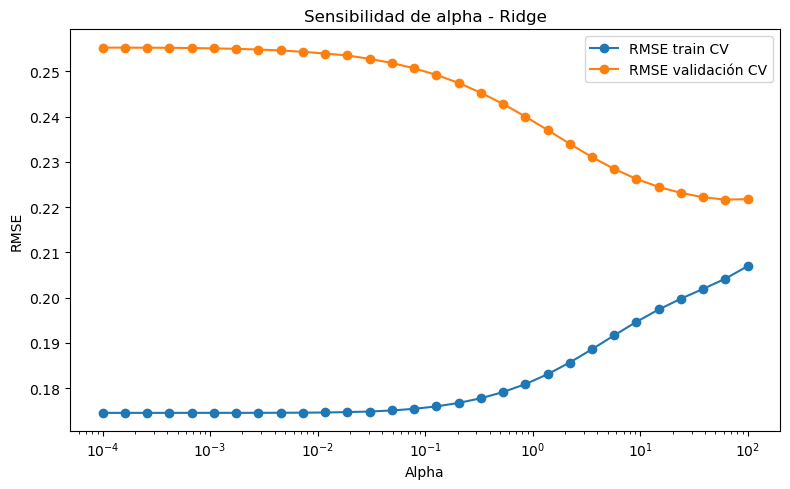

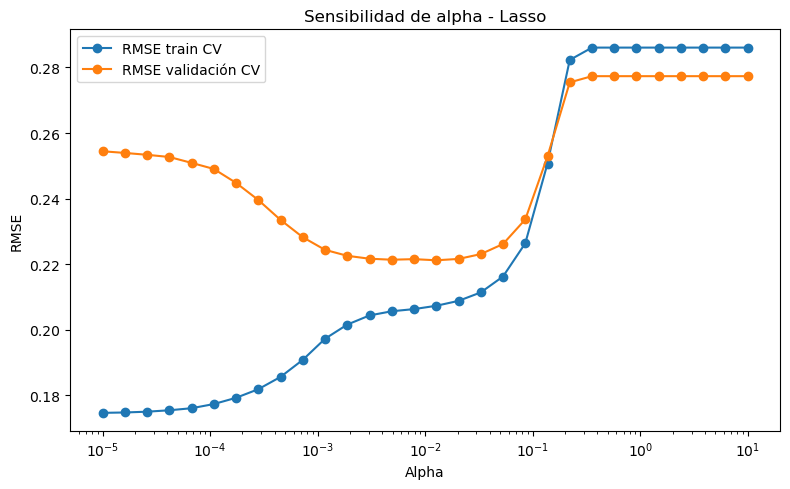

In [38]:
# Gráficos de sensibilidad

for nombre_modelo in ["Ridge", "Lasso"]:

    datos = df_sensibilidad[df_sensibilidad["modelo"] == nombre_modelo].copy()

    plt.figure(figsize=(8, 5))
    plt.plot(
        datos["alpha"],
        datos["rmse_train_cv"],
        marker="o",
        label="RMSE train CV"
    )
    plt.plot(
        datos["alpha"],
        datos["rmse_validacion_cv"],
        marker="o",
        label="RMSE validación CV"
    )

    plt.xscale("log")
    plt.xlabel("Alpha")
    plt.ylabel("RMSE")
    plt.title(f"Sensibilidad de alpha - {nombre_modelo}")
    plt.legend()
    plt.tight_layout()
    plt.show()

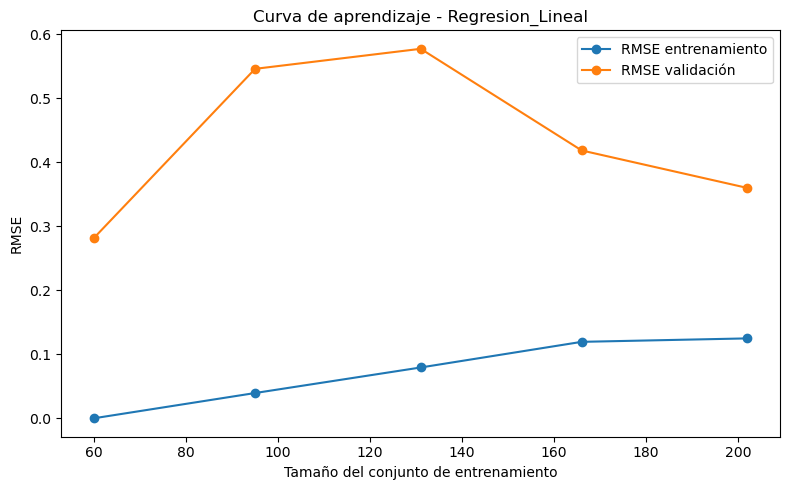

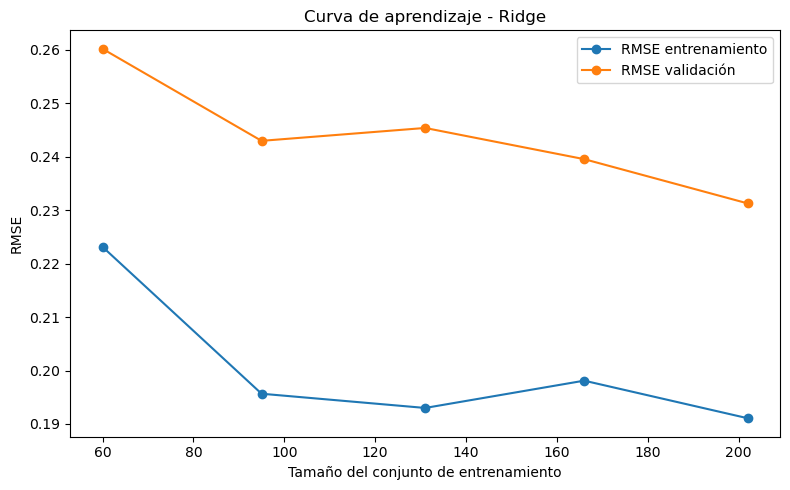

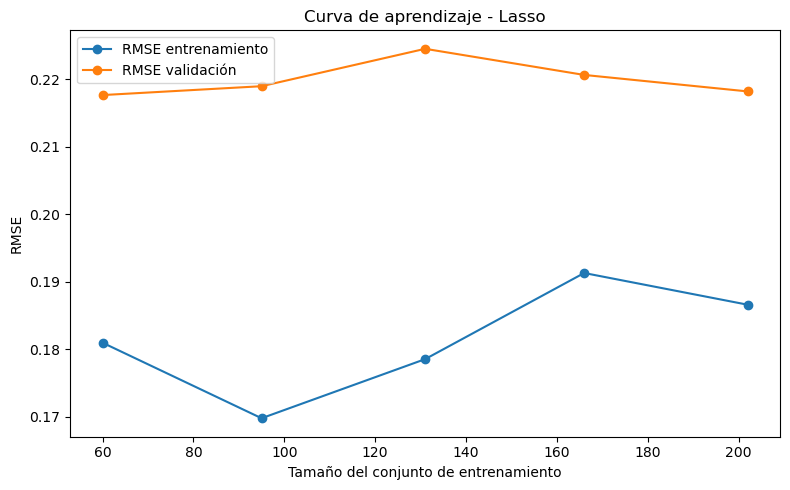

In [39]:
# Curvas de aprendizaje

for nombre_modelo, modelo in modelos.items():

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=modelo,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.3, 1.0, 5),
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rmse_train = -train_scores.mean(axis=1)
    rmse_validacion = -val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(
        train_sizes,
        rmse_train,
        marker="o",
        label="RMSE entrenamiento"
    )
    plt.plot(
        train_sizes,
        rmse_validacion,
        marker="o",
        label="RMSE validación"
    )

    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("RMSE")
    plt.title(f"Curva de aprendizaje - {nombre_modelo}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [40]:
# Comparación final de modelos

tabla_comparacion = df_resultados[
    [
        "modelo",
        "rmse_train",
        "rmse_test",
        "mae_test",
        "r2_train",
        "r2_test",
        "best_params"
    ]
].copy()

tabla_comparacion.columns = [
    "Modelo",
    "RMSE train",
    "RMSE test",
    "MAE test",
    "R2 train",
    "R2 test",
    "Hiperparámetros"
]

tabla_comparacion.round(6)

,Modelo,RMSE train,RMSE test,MAE test,R2 train,R2 test,Hiperparámetros
0,Ridge,0.208655,0.289404,0.213173,0.439044,0.274767,{'alpha': 76.97934308114426}
1,Lasso,0.212362,0.289610,0.214566,0.418938,0.273735,{'alpha': 0.01453835799826652}
2,Regresion_Lineal,0.197479,0.299422,0.222866,0.497525,0.223690,None


In [44]:
# Mejor modelo según RMSE test

mejor_fila = df_resultados.loc[df_resultados["rmse_test"].idxmin()]
mejor_nombre = mejor_fila["modelo"]

print("Mejor modelo:", mejor_nombre)
print("RMSE test:", mejor_fila["rmse_test"])
print("R2 test:", mejor_fila["r2_test"])

# Obtener variables

mejor_modelo = objetos_modelos[mejor_nombre]["modelo"]
preprocesador = mejor_modelo.named_steps["preprocessor"]
modelo_final = mejor_modelo.named_steps["modelo"]

nombres_variables = preprocesador.get_feature_names_out()
coeficientes = modelo_final.coef_

tabla_variables = pd.DataFrame({
    "variable": nombres_variables,
    "coeficiente": coeficientes
})

tabla_variables["coeficiente_abs"] = tabla_variables["coeficiente"].abs()

tabla_variables = tabla_variables.sort_values(
    "coeficiente_abs",
    ascending=False
).reset_index(drop=True)

tabla_variables[["variable", "coeficiente"]].round(6)

Mejor modelo: Ridge
RMSE test: 0.2894040275675393
R2 test: 0.27476718137367084


,variable,coeficiente
0,num__Rendimiento_lag1,0.155110
1,num__Radiación solar acumulada anual (MJ/m²/año),0.028570
2,cat__Departamento_CUNDINAMARCA,-0.023207
3,cat__Departamento_NARINO,0.023207
4,cat__Municipio_GACHETA,-0.021425
...,...,...
99,cat__Municipio_BUESACO,0.000288
100,cat__Municipio_EL ROSARIO,0.000212
101,cat__Municipio_GACHALA,-0.000184
102,cat__Municipio_EL COLEGIO,-0.000123
